# Part II, Notebook 06: Spending a Search Budget -- Grid vs. Random

**Course:** Summer School on AI for Economics and Finance · ESOMAS, University of Torino (August 24–26, 2026)  
**Session:** Day 1, 11:00 – 12:30 — Deep Equilibrium Nets (part II)  
**Slides:** `02_DEQN.pdf` — Part V, the hyperparameter space, grid search and random search (Bergstra & Bengio, 2012)  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC, University of Lausanne) — [course repository](https://github.com/sischei/summer-school-AI-for-economics-and-finance-2026)  

In [1]:
RUN_MODE = "teaching"   # one of: "smoke", "teaching", "production"
SEED = 0

You have a fixed compute budget, say 25 training runs, and several hyperparameters.
Where should you put the trials?

The slides quote Bergstra & Bengio (2012): **when only a few hyperparameters matter,
random search finds a better configuration than grid search at the same budget.** That
claim has a condition attached, and this notebook measures both the claim and the
condition.

| Section | Question | Cost |
|:--|:--|:--|
| 1 | Why *would* random beat grid? | no training, a picture |
| 2 | By how much, and does it depend on the number of axes? | no training, exact |
| 3 | Which of our hyperparameters actually matters? | ~14 short runs |
| 4 | Grid vs random on a real network | ~30 short runs |
| 5 | A case where grid search wins | ~30 short runs |

Sections 4 and 5 both cut against the headline, and that is deliberate. The projection
argument is a statement about *dimension counting*; Section 2 shows it is worth almost
nothing in one dimension and enormous in eight. Our real experiment lives at $d = 2$,
right where the theory says the edge should be small — so seeing it be small is a
confirmation, not a contradiction.

In [2]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "font.family":       "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

C_GRID, C_RAND = "#457b9d", "#e76f51"

np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow {tf.__version__} | RUN_MODE = {RUN_MODE}")

2026-08-18 23:03:57.481293: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787087037.497651  656958 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787087037.502436  656958 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-18 23:03:57.518527: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0 | RUN_MODE = teaching


---
## 1. The mechanism, in one picture

Take a budget of 25 trials and two hyperparameters. A $5\times 5$ grid and 25 uniform
random draws cost exactly the same.

Now suppose only the **horizontal** axis matters. Project both designs onto it and count
how many *distinct* values of the important hyperparameter each one actually tried.

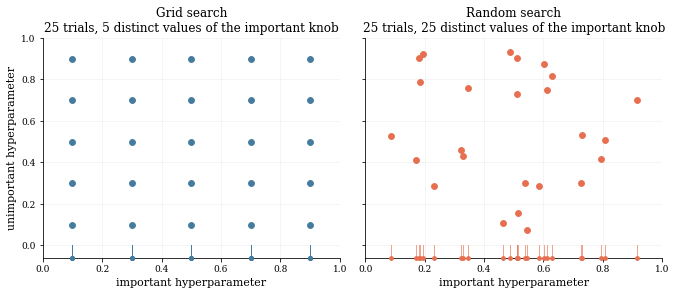

grid   : 25 trials ->  5 distinct important-axis values
random : 25 trials -> 25 distinct important-axis values

The grid spends 25 runs to resolve the axis that matters at 5 points,
because each of those 5 values is repeated 5 times along an axis that does not.


In [3]:
K = 5
rng_demo = np.random.default_rng(1)

g = np.linspace(0.1, 0.9, K)
grid_pts = np.array([[a, b] for a in g for b in g])
rand_pts = rng_demo.uniform(0.05, 0.95, size=(K*K, 2))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), sharey=True)
for ax, pts, col, name in [(axes[0], grid_pts, C_GRID,  "Grid search"),
                           (axes[1], rand_pts, C_RAND, "Random search")]:
    ax.scatter(pts[:, 0], pts[:, 1], s=34, color=col, zorder=3)
    for x in pts[:, 0]:                       # projection onto the important axis
        ax.plot([x, x], [0.0, -0.06], color=col, lw=0.9, alpha=0.7,
                clip_on=False, zorder=2)
    ax.scatter(pts[:, 0], np.full(len(pts), -0.06), s=14, color=col,
               clip_on=False, zorder=3)
    n_unique = len(np.unique(np.round(pts[:, 0], 6)))
    ax.set_title(f"{name}\n{len(pts)} trials, {n_unique} distinct values of the "
                 f"important knob")
    ax.set_xlabel("important hyperparameter")
    ax.set_xlim(0, 1); ax.set_ylim(-0.06, 1); ax.grid(alpha=0.15)
axes[0].set_ylabel("unimportant hyperparameter")
fig.tight_layout(); plt.show()

print(f"grid   : {len(grid_pts)} trials -> "
      f"{len(np.unique(np.round(grid_pts[:,0],6))):>2d} distinct important-axis values")
print(f"random : {len(rand_pts)} trials -> "
      f"{len(np.unique(np.round(rand_pts[:,0],6))):>2d} distinct important-axis values")
print("\nThe grid spends 25 runs to resolve the axis that matters at 5 points,")
print("because each of those 5 values is repeated 5 times along an axis that does not.")

---
## 2. How big is the edge, and what does it depend on?

The picture suggests random search should win, but a picture is not a measurement. Build
a response surface where we *know* the answer: the first coordinate matters, and the rest
matter by a factor $\delta$ that we control,

$$v(h_1, \dots, h_d) = (h_1 - h^\star)^2 + \delta \sum_{i \ge 2} (h_i - h^\star)^2 .$$

Give grid and random the **same budget** $k^d$, score both on the **same objective**, and
repeat thousands of times. This costs no training, so we can sweep both knobs the argument
depends on: the number of axes $d$, and how irrelevant the extra ones actually are.

edge = grid median / random median   (>1 favors random)

  delta    d=1 (k=5)    d=2 (k=5)    d=3 (k=4)    d=4 (k=3)    d=5 (k=3)    d=8 (k=2)
---------------------------------------------------------------------------------------
  0.000         0.6x        13.3x       139.8x       385.8x      3305.3x      8407.9x
  0.001         0.5x         8.0x        21.9x        28.0x        35.3x        35.7x
  0.010         0.6x         2.7x         4.9x         5.8x         6.1x         6.5x
  0.100         0.7x         1.1x         1.0x         1.2x         1.2x         1.2x
  1.000         0.6x         0.6x         0.6x         0.7x         0.7x         0.8x


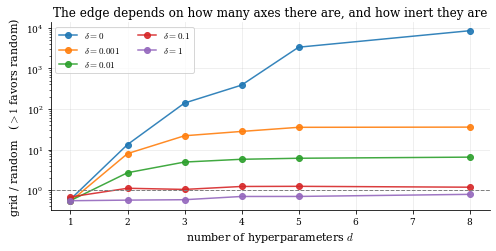


Three readings:
  Along a row: more axes -> bigger edge. At delta = 0 it runs from 13x at d=2 to 8408x at d=8.
  Down a column: as the extra axes stop being inert the edge collapses. At delta = 1, where every axis matters equally, the GRID wins everywhere.
  At d = 1 the grid always wins (1.7x): a grid on one axis is a
  stratified sample, and stratification beats independent draws.


In [4]:
import itertools

STAR  = 0.37
N_REP = {"smoke": 500, "teaching": 2000, "production": 8000}[RUN_MODE]
rng   = np.random.default_rng(SEED)

def edge(d, k, delta, n_rep=N_REP):
    """Median best-found value for a k^d grid vs the same number of random draws."""
    budget = k**d
    def v(H):
        H = np.atleast_2d(H)
        return (H[:, 0] - STAR)**2 + delta * ((H[:, 1:] - STAR)**2).sum(axis=1)
    g, r = [], []
    for _ in range(n_rep):
        ax = np.clip(np.arange(k)/k + rng.uniform(0, 1.0/k), 0, 1)   # random grid offset
        g.append(v(np.array(list(itertools.product(ax, repeat=d)))).min())
        r.append(v(rng.uniform(0, 1, (budget, d))).min())
    return np.median(g) / np.median(r)

DIMS   = [(1, 5), (2, 5), (3, 4), (4, 3), (5, 3), (8, 2)]
DELTAS = [0.0, 0.001, 0.01, 0.1, 1.0]

table = np.array([[edge(d_, k_, dl) for d_, k_ in DIMS] for dl in DELTAS])

hdr = "  ".join(f"d={d_} (k={k_})".rjust(11) for d_, k_ in DIMS)
print(f"edge = grid median / random median   (>1 favors random)\n")
print(f"{'delta':>7s}  " + hdr)
print("-" * (9 + 13*len(DIMS)))
for i, dl in enumerate(DELTAS):
    print(f"{dl:>7.3f}  " + "  ".join(f"{v:10.1f}x" for v in table[i]))

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, dl in enumerate(DELTAS):
    ax.plot([d_ for d_, _ in DIMS], table[i], "o-",
            label=rf"$\delta = {dl:g}$", alpha=0.9)
ax.axhline(1.0, color="grey", ls="--", lw=1)
ax.set_yscale("log")
ax.set_xlabel("number of hyperparameters $d$")
ax.set_ylabel("grid / random   ($>1$ favors random)")
ax.set_title("The edge depends on how many axes there are, and how inert they are")
ax.legend(fontsize=9, ncol=2)
fig.tight_layout(); plt.show()

print("\nThree readings:")
print(f"  Along a row: more axes -> bigger edge. At delta = 0 it runs from "
      f"{table[0][1]:.0f}x at d=2 to {table[0][-1]:.0f}x at d=8.")
print(f"  Down a column: as the extra axes stop being inert the edge collapses. At"
      f" delta = 1, where every axis matters equally, the GRID wins everywhere.")
print(f"  At d = 1 the grid always wins ({1/table[0][0]:.1f}x): a grid on one axis is a")
print("  stratified sample, and stratification beats independent draws.")

---
## 3. Which knob actually matters?

Now the real thing: fit the Genz Gaussian on $[0,1]^2$ with a small MLP, the same testbed
as notebook `02_07`. Two hyperparameters:

- the **learning rate**, log-uniform on $[10^{-4}, 10^{-1}]$;
- the **$L_2$ penalty**, log-uniform on $[10^{-8}, 10^{-6}]$.

Before searching, measure how much each one moves the validation loss. Do not take the
labels "important" and "unimportant" on faith — that is precisely the assumption the
whole argument rests on.

In [5]:
# ----------------------------------------------------------------
# Testbed and one trial
# ----------------------------------------------------------------
d = 2
def genz_gaussian(X, c, w): return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))

_r = np.random.RandomState(7)
c_param = _r.uniform(1.0, 3.0, size=d)
w_param = _r.uniform(0.2, 0.8, size=d)

n_train, n_val = 1000, 2000
X_train = np.random.uniform(0, 1, (n_train, d)).astype(np.float32)
y_train = genz_gaussian(X_train, c_param, w_param).astype(np.float32)
X_val   = np.random.uniform(0, 1, (n_val, d)).astype(np.float32)
y_val   = genz_gaussian(X_val, c_param, w_param).astype(np.float32)

EPOCHS   = {"smoke": 15, "teaching": 25, "production": 40}[RUN_MODE]
K_SEARCH = {"smoke": 3,  "teaching": 4,  "production": 5}[RUN_MODE]
N_SEEDS  = {"smoke": 1,  "teaching": 2,  "production": 5}[RUN_MODE]
LR_LO, LR_HI = -4.0, -1.0          # log10 bounds, learning rate
L2_LO, L2_HI = -8.0, -6.0          # log10 bounds, L2 penalty
print(f"{EPOCHS} epochs/trial, {K_SEARCH}x{K_SEARCH} = {K_SEARCH**2} trials per method, "
      f"{N_SEEDS} seed(s)")


def trial(lr, l2, seed=1000, dropout=0.0):
    """Train one small MLP and return its best validation MSE."""
    tf.keras.utils.set_random_seed(seed)
    m = keras.Sequential([keras.Input((d,))])
    for _ in range(3):
        m.add(layers.Dense(64, activation="tanh",
                           kernel_regularizer=keras.regularizers.l2(l2)))
        if dropout > 0:
            m.add(layers.Dropout(dropout))
    m.add(layers.Dense(1))
    m.compile(optimizer=keras.optimizers.Adam(lr), loss="mse")
    h = m.fit(X_train, y_train, validation_data=(X_val, y_val),
              epochs=EPOCHS, batch_size=64, verbose=0)
    return float(min(h.history["val_loss"]))

25 epochs/trial, 4x4 = 16 trials per method, 2 seed(s)


2026-08-18 23:04:06.522188: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


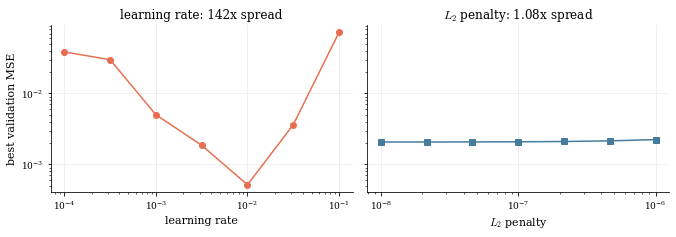

learning rate moves the loss by    141.9x over its range
L2 penalty   moves the loss by     1.08x over its range

The optimum sits near lr = 1.0e-02, and it is sharp:
that is exactly the situation where the grid's coarse resolution costs it.
(47s)


In [6]:
# ----------------------------------------------------------------
# One-at-a-time sensitivity: how much does each axis move the loss?
# ----------------------------------------------------------------
t0 = time.time()
lrs   = 10.0 ** np.linspace(LR_LO, LR_HI, 7)
l2s   = 10.0 ** np.linspace(L2_LO, L2_HI, 7)
v_lr  = [trial(float(a), 1e-7) for a in lrs]
v_l2  = [trial(3e-3, float(b))  for b in l2s]

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.4), sharey=True)
axes[0].loglog(lrs, v_lr, "o-", color=C_RAND)
axes[0].set_xlabel("learning rate"); axes[0].set_ylabel("best validation MSE")
axes[0].set_title(f"learning rate: {max(v_lr)/min(v_lr):.0f}x spread")
axes[1].loglog(l2s, v_l2, "s-", color=C_GRID)
axes[1].set_xlabel("$L_2$ penalty")
axes[1].set_title(f"$L_2$ penalty: {max(v_l2)/min(v_l2):.2f}x spread")
fig.tight_layout(); plt.show()

print(f"learning rate moves the loss by {max(v_lr)/min(v_lr):8.1f}x over its range")
print(f"L2 penalty   moves the loss by {max(v_l2)/min(v_l2):8.2f}x over its range")
print(f"\nThe optimum sits near lr = {lrs[int(np.argmin(v_lr))]:.1e}, and it is sharp:")
print("that is exactly the situation where the grid's coarse resolution costs it.")
print(f"({time.time()-t0:.0f}s)")

---
## 4. Grid versus random on the real network

Same number of trials, same epochs per trial, same network seed. The only difference is
where in the hyperparameter space the trials sit.

We are at $d = 2$ with one nearly inert axis, so Section 2 predicts an edge of roughly
$10\times$ for random search. Expect the measurement to be noisier than that: unlike the
synthetic surface, retraining at a slightly different learning rate moves the validation
loss by a factor of several through the optimizer trajectory alone. With two seeds and a
budget of $k^2$ trials, the outcome can flip.

In [7]:
def run_grid(k, seed, dropout=0.0):
    a = 10.0 ** np.linspace(LR_LO, LR_HI, k)
    b = 10.0 ** np.linspace(L2_LO, L2_HI, k)
    return [trial(float(x), float(y), seed, dropout) for x in a for y in b]

def run_random(k, seed, dropout_hi=0.0):
    r = np.random.default_rng(seed)
    a = 10.0 ** r.uniform(LR_LO, LR_HI, k*k)
    b = 10.0 ** r.uniform(L2_LO, L2_HI, k*k)
    dr = r.uniform(0.0, dropout_hi, k*k) if dropout_hi > 0 else np.zeros(k*k)
    return [trial(float(x), float(y), seed, float(z)) for x, y, z in zip(a, b, dr)]

t0 = time.time()
grid_runs, rand_runs = [], []
for sd in range(N_SEEDS):
    gv = run_grid(K_SEARCH, 1000 + sd)
    rv = run_random(K_SEARCH, sd)
    grid_runs.append(gv); rand_runs.append(rv)
    print(f"seed {sd}: grid best = {min(gv):.3e}   random best = {min(rv):.3e}")
print(f"({time.time()-t0:.0f}s)")

gb = np.array([min(v) for v in grid_runs])
rb = np.array([min(v) for v in rand_runs])
print(f"\ngrid   median best: {np.median(gb):.3e}")
print(f"random median best: {np.median(rb):.3e}")
print(f"random wins on {int((rb < gb).sum())}/{N_SEEDS} seed(s)")

seed 0: grid best = 5.018e-04   random best = 2.179e-04


seed 1: grid best = 3.022e-03   random best = 2.966e-04
(257s)

grid   median best: 1.762e-03
random median best: 2.573e-04
random wins on 2/2 seed(s)


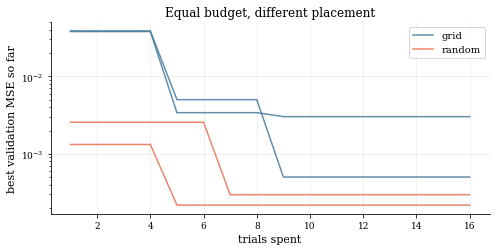

In [8]:
# ----------------------------------------------------------------
# Best-so-far curves: what you would have had after t trials
# ----------------------------------------------------------------
def best_so_far(v): return np.minimum.accumulate(np.asarray(v))

fig, ax = plt.subplots(figsize=(7, 3.6))
for i, (gv, rv) in enumerate(zip(grid_runs, rand_runs)):
    ax.plot(np.arange(1, len(gv)+1), best_so_far(gv), color=C_GRID,
            alpha=0.85, label="grid" if i == 0 else None)
    ax.plot(np.arange(1, len(rv)+1), best_so_far(rv), color=C_RAND,
            alpha=0.85, label="random" if i == 0 else None)
ax.set_yscale("log"); ax.set_xlabel("trials spent")
ax.set_ylabel("best validation MSE so far")
ax.set_title("Equal budget, different placement")
ax.legend(); fig.tight_layout(); plt.show()

### Reading the result honestly

Two effects that Section 2's clean surface does not have are at work here.

- **The objective is noisy.** Two runs at nearby learning rates differ by a factor of
  several for reasons that have nothing to do with the hyperparameters. A best-of-$n$
  statistic under that much noise is partly a lottery, which is why the seeds disagree.
- **The grid gets free noise-averaging.** Each of its $k$ learning rates is evaluated $k$
  times, once per (inert) $L_2$ value, and we keep the best of them. Random search
  evaluates $k^2$ *different* learning rates once each. When the response is noisy,
  repeated draws at a good setting can beat a single draw at a better one.

Both effects shrink as the search space widens: with six spare axes rather than one, the
grid's repeats stop being a lucky bonus and become the entire budget.

---
## 5. A case where grid search wins outright

The projection argument needs the extra axes to be **irrelevant**. If one is instead
*harmful*, the grid is guaranteed to try its best value — the endpoint — alongside every
learning rate, while random draws almost never land there.

Dropout on this problem is exactly such an axis: with 1,000 clean training points and a
small network there is nothing to regularize, so any dropout above zero only hurts.

In [9]:
t0 = time.time()
gv_do = run_grid(K_SEARCH, 1000)                    # dropout = 0 on every grid point
rv_do = run_random(K_SEARCH, 0, dropout_hi=0.5)     # dropout drawn from [0, 0.5]

print(f"grid   (dropout = 0 always)    best = {min(gv_do):.3e}")
print(f"random (dropout ~ U[0, 0.5])   best = {min(rv_do):.3e}")
print(f"\nThe grid wins by {min(rv_do)/min(gv_do):.0f}x here. Neither algorithm changed --")
print("only whether the second axis was irrelevant or actively harmful.")
print(f"({time.time()-t0:.0f}s)")

grid   (dropout = 0 always)    best = 5.018e-04
random (dropout ~ U[0, 0.5])   best = 4.652e-03

The grid wins by 9x here. Neither algorithm changed --
only whether the second axis was irrelevant or actively harmful.
(145s)


---
## 6. What to remember

1. **The projection argument is about dimension counting.** At the same budget, random
   search resolves every axis at $n$ distinct values while a $k^d$ grid resolves each at
   only $k$. Section 2 measured the payoff and it is worth remembering both directions:
   the grid *wins* at $d=1$, and random wins by orders of magnitude by $d=8$ — but only
   when the extra axes are genuinely inert.

2. **The condition does the work.** As soon as the spare axes start to matter ($\delta
   \gtrsim 0.1$ in Section 2) the advantage vanishes, and when every axis matters equally
   the grid is the better design. "Random beats grid" is not a law; it is a statement
   about search spaces that are mostly padding.

3. **Prefer random search because real search spaces are mostly padding.** Depth, width,
   activation, learning rate, batch size, regularization, warm-up, initialization: most
   will not matter for your problem, and you do not know in advance which.

4. **Do not expect a clean win in two dimensions.** Section 4 is the honest version: on a
   noisy objective with one spare axis, the seeds can disagree.

5. **Check whether an axis is irrelevant or harmful.** Section 5 is a genuine
   counterexample. Two minutes of one-at-a-time sweeps (Section 3) tell you which
   hyperparameters deserve the budget and which should simply be fixed.

6. **Neither method uses the budget well.** Both spend the full epoch count on
   configurations that were visibly hopeless after two epochs. That, not placement, is
   the bigger lever at small budgets — and it is what notebook `02_07` does next.

### Reference

Bergstra, J., & Bengio, Y. (2012). *Random search for hyper-parameter optimization.*
Journal of Machine Learning Research 13, 281–305.